### This project presents an AI-powered Twitter Sentiment Analysis system developed using Natural Language Processing and Machine Learning techniques.
### The Sentiment140 dataset is utilized to classify tweets as positive or negative based on their textual content.
### Comprehensive text preprocessing, TF-IDF feature extraction, and multiple machine learning algorithms are implemented and evaluated.
### The final system accurately predicts sentiment from new tweets and demonstrates the practical application of AI in social media analytics.


### STEP 1 : IMPORT LIBRARIES
#### Import all required libraries for data processing, visualization, NLP, and machine learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

### STEP 2 : DOWNLOAD NLTK RESOURCES
#### Download necessary NLP resources such as stopwords and lemmatization data.

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### STEP 3 : LOAD DATASET
#### Load the Sentiment140 dataset into a DataFrame for analysis.


In [3]:
columns = [
    'target',
    'id',
    'date',
    'flag',
    'user',
    'text'
]

df = pd.read_csv(
    "/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    names=columns
)

df.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


### STEP 4 : DATA OVERVIEW
#### Understand the dataset structure, size, and data quality.

In [5]:
print(df.shape)

df.info()

df.isnull().sum()

(1600000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

### STEP 5 : KEEP REQUIRED COLUMNS
#### Retain only the columns needed for sentiment analysis.

In [6]:
df = df[['target','text']]
df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


### STEP 6 : CONVERT LABELS
#### Convert sentiment labels into a binary format for model training.

In [7]:
df['target'] = df['target'].replace(4,1)

df['target'].value_counts()

target
0    800000
1    800000
Name: count, dtype: int64

### STEP 7 : VISUALIZE SENTIMENT DISTRIBUTION
#### Examine the balance between positive and negative sentiments.

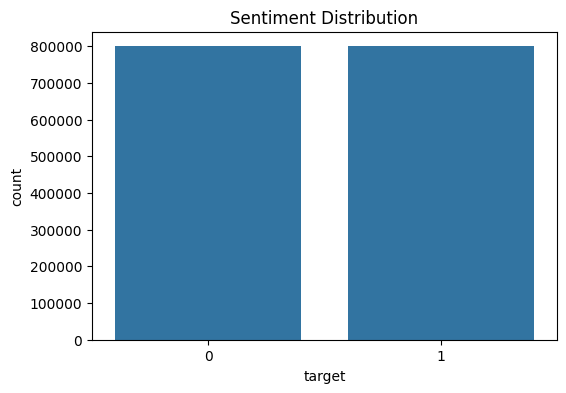

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['target']
)

plt.title("Sentiment Distribution")
plt.show()

### STEP 8 : TEXT CLEANING FUNCTION
#### Remove unwanted text elements and normalize tweet content.

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

### STEP 9 : CLEAN TWEETS
#### Apply preprocessing to prepare tweets for feature extraction.

In [10]:
df['clean_text'] = df['text'].apply(clean_text)

df.head()

,target,text,clean_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",thats bummer shoulda got david carr third day
1,0,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,0,@Kenichan I dived many times for the ball. Man...,dived many time ball managed save rest go bound
3,0,my whole body feels itchy and like its on fire,whole body feel itchy like fire
4,0,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see


### STEP 10 : CHECK SAMPLE TWEETS
#### Verify that text cleaning is working correctly.

In [11]:
for i in range(5):
    print("Original:")
    print(df['text'][i])

    print("\nCleaned:")
    print(df['clean_text'][i])

    print("="*70)

Original:
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

Cleaned:
thats bummer shoulda got david carr third day
Original:
is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!

Cleaned:
upset cant update facebook texting might cry result school today also blah
Original:
@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds

Cleaned:
dived many time ball managed save rest go bound
Original:
my whole body feels itchy and like its on fire 

Cleaned:
whole body feel itchy like fire
Original:
@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. 

Cleaned:
behaving im mad cant see


### STEP 11 : TF-IDF VECTORIZATION
#### Transform text data into numerical features for machine learning.

In [12]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(df['clean_text'])

y = df['target']

### STEP 12 : TRAIN TEST SPLIT
#### Separate data into training and testing sets for evaluation.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### STEP 13 : LOGISTIC REGRESSION
#### Train a baseline sentiment classification model.

In [14]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.773771875


### STEP 14 : NAIVE BAYES
#### Train a probabilistic model suitable for text classification.

In [15]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_acc = accuracy_score(
    y_test,
    nb_pred
)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.758065625


### STEP 15 : COMPARE MODELS
#### Evaluate and compare the accuracy of all trained models.

In [16]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes"  
    ],

    "Accuracy":[
        lr_acc,
        nb_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.773772
1,Naive Bayes,0.758066


### STEP 16 : ACCURACY COMPARISON GRAPH
#### Visualize model performance for easier comparison.

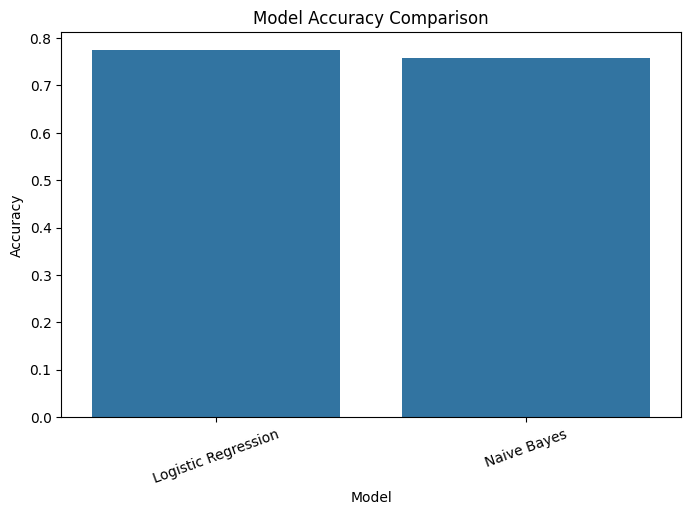

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

### STEP 17 : CONFUSION MATRIX
#### Analyze correct and incorrect predictions made by the model.

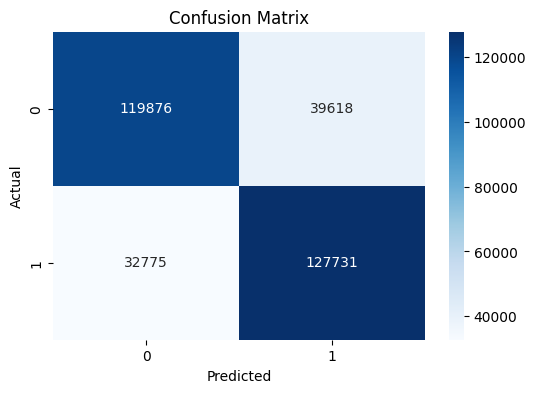

In [18]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### STEP 18 : CLASSIFICATION REPORT
#### Measure precision, recall, F1-score, and overall performance.

In [19]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.79      0.75      0.77    159494
           1       0.76      0.80      0.78    160506

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



### STEP 19 : SENTIMENT PREDICTION FUNCTION
#### Create a function to predict sentiment for new tweets.

In [20]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    vectorized = vectorizer.transform(
        [cleaned]
    )

    prediction = lr_model.predict(
        vectorized
    )[0]

    if prediction == 1:
        return "Positive 😊"

    else:
        return "Negative 😔"

### STEP 20 : TEST CUSTOM TWEETS
#### Validate the model using user-defined tweet examples.

In [24]:
sample1 = "This is the worst day ever.."

sample2 = "I am extremely happy today"

print(
    predict_sentiment(sample1)
)

print(
    predict_sentiment(sample2)
)

Negative 😔
Positive 😊


### STEP 21 : SAVE MODEL
#### Store the trained model and vectorizer for future use or deployment.

In [25]:
import pickle

pickle.dump(
    lr_model,
    open("twitter_sentiment_model.pkl","wb")
)

pickle.dump(
    vectorizer,
    open("tfidf_vectorizer.pkl","wb")
)

print("Model Saved Successfully")

Model Saved Successfully
